<a href="https://colab.research.google.com/github/purplecat19/Synapse_LearningPhase/blob/week-4/Devanshi_SynapseLP_Task3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Task 3**

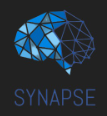

# Unsupervised Learning: Clustering, Dimensionality Reduction, and Association Rules

Unsupervised learning can be broken down into three main tasks:

- **Clustering**  
- **Dimensionality Reduction**  
- **Association Rules**  

Let's explore these topics :))  

Clustering is an unsupervised learning technique used to group similar data points together. It's widely used in applications like customer segmentation, anomaly detection, and more. In this task, we'll explore different clustering algorithms and visualize their results.  

Dimensionality reduction is a technique used to reduce the number of features in a dataset while retaining most of the important information. This helps in better visualization, faster computation, and noise reduction.  

Association rules are used to discover interesting relationships between variables in large datasets. A common example is market basket analysis, where we find products that are frequently bought together.  

In this task, we'll work with the **Online Retail dataset**, which contains transactional data from an e-commerce retailer. We'll use this dataset to:

- Cluster customers based on their purchasing behavior.  
- Reduce feature dimensions for visualization using PCA.  
- Discover associations between products using association rule mining.  


In [ ]:
# Basic Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# For clustering
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score
# For association rules
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules
# For interactive widgets
from ipywidgets import interact
# Misc
import warnings
warnings.filterwarnings("ignore")

Use the Online retail dataset for this task:https://drive.google.com/drive/folders/1jZMLVW7LboD95K-HznZSsVUwrC-k-QOG?usp=sharing

Mount the drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Load the dataset
df = pd.read_csv("/content/drive/My Drive/synapse/Online Retail.csv", encoding='latin1') #Add the path in the ""

Understanding the data

In [ ]:
# print 1st few rows of the dataset, its shape and the columns
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,01-12-2010 08:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,01-12-2010 08:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,01-12-2010 08:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,01-12-2010 08:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,01-12-2010 08:26,3.39,17850.0,United Kingdom


In [ ]:
df.shape

(541909, 8)

In [ ]:
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='object')

In [ ]:
# check for null values
df.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,1454
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,135080
Country,0


Analyse the Missing Values

From the previous output, we observe:
- `Description` has **1454 missing values** — this is a small amount compared to the total rows. Since association rules require product names, we will **drop rows with missing `Description`**.
- `CustomerID` has **135080 missing values**, which is a large amount. Whether to keep or drop these rows depends on our analysis:
  - If we want to do **customer-level analysis or clustering**, we must have `CustomerID`. In that case, we will **drop rows where `CustomerID` is missing**.
  - If we only want **product-level analysis** (e.g., frequent items), we can keep them.
  
In this task, we will proceed with **customer-level analysis**, so we will **drop rows where `CustomerID` is missing**.


In [ ]:
#Drop the rows with missing\null values
df.dropna(subset=['Description', 'CustomerID'], inplace=True)
#Re-check the shape and missing values
df.shape

(406829, 8)

In [ ]:
# Remove rows with negative or zero Quantity
df = df[df['Quantity'] > 0]
# Remove rows with zero or negative UnitPrice
df = df[df['UnitPrice'] > 0]
# Remove cancelled invoices (those starting with 'C')
df = df[df['InvoiceNo'].astype(str).str.startswith('C') == False]

In [ ]:
# Verify there are no negative values left
df.describe()
# Quick summary after cleaning

,Quantity,UnitPrice,CustomerID
count,397884.000000,397884.000000,397884.000000
mean,12.988238,3.116488,15294.423453
std,179.331775,22.097877,1713.141560
min,1.000000,0.001000,12346.000000
25%,2.000000,1.250000,13969.000000
50%,6.000000,1.950000,15159.000000
75%,12.000000,3.750000,16795.000000
max,80995.000000,8142.750000,18287.000000


In [ ]:
duplicate_count = df.duplicated().sum()
print(duplicate_count)

5192


In [ ]:
# Drop duplicate rows
df.drop_duplicates(inplace=True)
# Verify again
new_dupe_count = df.duplicated().sum()
print(new_dupe_count)

0


In [ ]:
# Identify the top 10 countries with the highest number of transactions
# Hint: Use a **horizontal bar chart** to visualize the results.
top_10_countries = df['Country'].value_counts().head(10)
print(top_10_countries)

Country
United Kingdom    349203
Germany             9025
France              8326
EIRE                7226
Spain               2479
Netherlands         2359
Belgium             2031
Switzerland         1841
Portugal            1453
Australia           1181
Name: count, dtype: int64


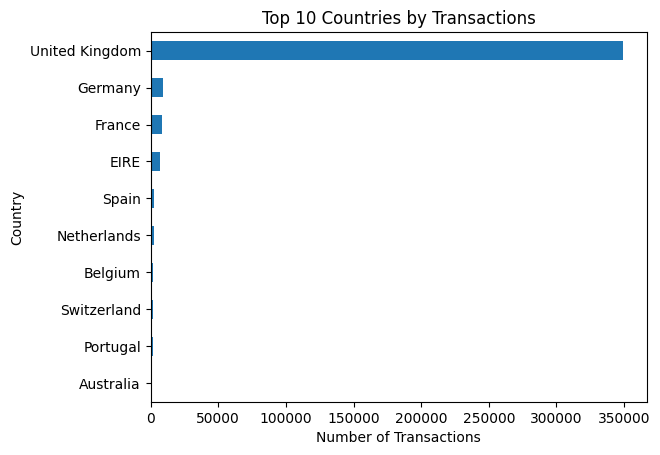

In [ ]:
top_10_countries.sort_values().plot(kind='barh')
plt.title("Top 10 Countries by Transactions")
plt.xlabel("Number of Transactions")
plt.ylabel("Country")
plt.show()

Pre-Processing the data for PCA and clustering

In [ ]:
#Create a new TotalAmount column(Quantity * Unit price)
df['TotalAmount'] = df['Quantity'] * df['UnitPrice']
# Aggregate numeric data at the customer level   (making each row 1 customer instead of 1 transaction)
customer_df = df.groupby('CustomerID').agg({
     'Quantity': 'sum',
     'TotalAmount': 'sum'
 }).reset_index()

# Keep only numeric columns for PCA (Principal Component Analysis - for dimensionality reduction)
pca_data = customer_df.drop('CustomerID', axis=1)  #dropping customer id coz its an identifier not a feature
pca_data.head()

,Quantity,TotalAmount
0,74215,77183.60
1,2458,4310.00
2,2341,1797.24
3,631,1757.55
4,197,334.40


In [ ]:
#Standardize the numeric features
scaler = StandardScaler()
scaled_data = scaler.fit_transform(pca_data)
scaled_df = pd.DataFrame(scaled_data, columns=pca_data.columns)
scaled_df.head()

,Quantity,TotalAmount
0,14.480825,8.363010
1,0.251903,0.251699
2,0.228702,-0.027988
3,-0.110379,-0.032406
4,-0.196438,-0.190812


Now that you have understood how to preprocess data for PCA through Online Retail dataset, we will apply similar steps to a new dataset: the Customer dataset.

This will help reinforce your understanding of dimensionality reduction and Clustering, while working with a dataset that is easier to visualize in 2D and 3D.

From this point onward, we will use the Customer_Data dataset:https://drive.google.com/drive/folders/1jZMLVW7LboD95K-HznZSsVUwrC-k-QOG?usp=sharing

In [ ]:
# Load the dataset
df_2 = pd.read_csv("/content/drive/My Drive/synapse/Customer_Data.csv") # Continue with the routine

In [ ]:
df_2.head()

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONE_OFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONE_OFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


In [ ]:
#Check for missing values
df_2.isnull().sum()

,0
CUST_ID,0
BALANCE,0
BALANCE_FREQUENCY,0
PURCHASES,0
ONE_OFF_PURCHASES,0
INSTALLMENTS_PURCHASES,0
CASH_ADVANCE,0
PURCHASES_FREQUENCY,0
ONE_OFF_PURCHASES_FREQUENCY,0
PURCHASES_INSTALLMENTS_FREQUENCY,0


In [ ]:
#Drop CUST_ID (identifier, not useful for PCA)
df_2.drop('CUST_ID', axis=1, inplace=True)

In [ ]:
#Handle missing values if needed
# Option: fill missing values with median (common in financial datasets)
df_2.fillna(df_2.median(), inplace=True)

Explain
Why did we fill the missing values in this dataset instead of dropping them, like we did in the previous dataset?

Answer:<br>
we filled missing values here because each row is an entire customer so deleting a row means losing the whole person from analysis, which is a big loss of information. <br>
in the previous online retail dataset, each row was just one of many transactions, some made by the same customr, so dropping a few columns was acceptable.

(we used median to fill instead of mean coz it is more robust to outliers)

In [ ]:
#Standardize numeric features
scaler_2 = StandardScaler()
scaled_data_2 = scaler_2.fit_transform(df_2)

In [ ]:
#Verify scaled data
scaled_df_2 = pd.DataFrame(scaled_data_2, columns=df_2.columns)  #convert numpy array to dataframe
scaled_df_2.head()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONE_OFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONE_OFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,-0.731989,-0.249434,-0.424900,-0.356934,-0.349079,-0.466786,-0.806490,-0.678661,-0.707313,-0.675349,-0.476070,-0.511333,-0.960378,-0.528979,-0.302400,-0.525551,0.36068
1,0.786961,0.134325,-0.469552,-0.356934,-0.454576,2.605605,-1.221758,-0.678661,-0.916995,0.573963,0.110074,-0.591796,0.688678,0.818642,0.097500,0.234227,0.36068
2,0.447135,0.518084,-0.107668,0.108889,-0.454576,-0.466786,1.269843,2.673451,-0.916995,-0.675349,-0.476070,-0.109020,0.826100,-0.383805,-0.093293,-0.525551,0.36068
3,0.049099,-1.016953,0.232058,0.546189,-0.454576,-0.368653,-1.014125,-0.399319,-0.916995,-0.258913,-0.329534,-0.551565,0.826100,-0.598688,-0.228307,-0.525551,0.36068
4,-0.358775,0.518084,-0.462063,-0.347294,-0.454576,-0.466786,-1.014125,-0.399319,-0.916995,-0.675349,-0.476070,-0.551565,-0.905410,-0.364368,-0.257266,-0.525551,0.36068


# Dimensionality Reduction using PCA - Principal Component Analysis

Ref.: https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html

Theory: https://towardsdatascience.com/the-mathematics-behind-principal-component-analysis-fff2d7f4b643 and https://rlrocha.medium.com/choosing-the-number-of-components-of-principal-component-analysis-36902a887520

Theory + Implementation.: https://youtu.be/OFyyWcw2cyM (Jump to timestamp - 13:50 for PCA implementaion)

Before we start of with this, **explain what PCA is and why is it necessary?**

Answer:

Principal Component Analysis (PCA) is a dimensionality reduction technique used to simplify complex datasets. Its main job is to take a dataset with many features and reduce them to just a few new features (principal components), while keeping as much of the original info as possible.

it is necessary for:
- to visualize data as we can't make a graph with 10 different axes for 10 diffeent features. So PCA can club these 10 features down into 2 or 3 principal components, which we can then easily plotand identify clusters or patterns.
- to improve model's performance since many ML algos get slower or less accurate when they have way too many features. So, by reducing the number of features to only the most important ones, PCA helps models run faster and often produce better, less noisy results.

Reduce the number of dimensions using PCA,

Hints:
1. Initialise instance of PCA and set *n_components* to 0.9 and *random_state* to 20.
2. Fit X_scaled over the PCA instance created
3. Transform X_scaled over the fitted PCA instance and store it in a variable named data_pca.

In [ ]:
#Code here
pca = PCA(n_components=0.9, random_state=20)
pca.fit(scaled_data_2)
data_pca = pca.transform(scaled_data_2)

In [ ]:
# Check the shape of the transformed data
data_pca.shape
#If everything's correct should print (8950,10)

(8950, 10)

Go through these and display the explained_variance_ratio_ and plot the same

Ref: https://saturncloud.io/blog/what-is-sklearn-pca-explained-variance-and-explained-variance-ratio-difference/ and https://www.jcchouinard.com/pca-explained-variance/

In [ ]:
# Explained variance ratio
print(pca.explained_variance_ratio_)

[0.27297671 0.2031378  0.08813182 0.07479524 0.06224729 0.05740056
 0.04883426 0.04299203 0.03798259 0.03080002]


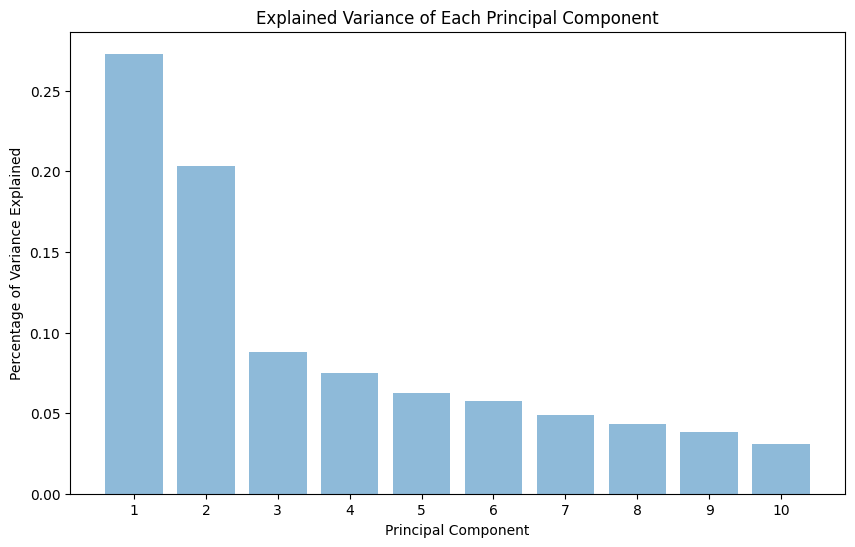

In [ ]:
# Plotting the explained variance
plt.figure(figsize=(10, 6))
plt.bar(range(1, len(pca.explained_variance_ratio_) + 1), pca.explained_variance_ratio_, alpha=0.5, align='center')
plt.title('Explained Variance of Each Principal Component')
plt.xlabel('Principal Component')
plt.xticks(range(1, len(pca.explained_variance_ratio_) + 1))
plt.ylabel('Percentage of Variance Explained')
plt.show()

What did you understand by Explained Variance


Answer:

explained variance tells how much of the original, messy information is successfully captured by the new, simpler model.

all data has variance (how spread out or complex the info is). <br>
A model like PCA creates a few new features to represent that complexity in a simpler way.

so the explained variance tells us how much of the original data's variance was explained by each of the principal component. Explained variance ratio is the cumulative sum and gives the percentage for each principal component. A high percentage means the simplified version is a very good representation of the original, complex data.

# K-Means Clustering (Partition-Based Clustering)

K-means clustering is an essential partitioning algorithm used to categorize a dataset into 'k' distinct, non-overlapping clusters. Each data point is assigned to the cluster with the nearest mean or centroid, symbolizing the cluster's center. The primary goal of the algorithm is to minimize the sum of squared distances between data points and their respective cluster centroids.

For an in-depth exploration of K-means clustering, you can refer to this comprehensive article on Analytics Vidhya: [Comprehensive Guide to K-means Clustering](https://www.analyticsvidhya.com/blog/2019/08/comprehensive-guide-k-means-clustering/).

For a deeper understanding of the mathematical underpinnings of K-means clustering, Wikipedia is a valuable resource. You can explore the Wikipedia page on K-means clustering for a detailed description: [K-means Clustering Wikipedia](https://en.wikipedia.org/wiki/K-means_clustering). This will help you grasp the mathematical intricacies of the algorithm and its applications in machine learning.

Here are some more resources to help you understand these concepts in depth:https://www.youtube.com/watch?v=4b5d3muPQmA

2D Visualization


In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from ipywidgets import interact

# Function to perform K-Means and plot clusters
def kmeans_clustering(num_clusters):
    kmeans = KMeans(n_clusters=num_clusters, random_state=42)
    kmeans_labels = kmeans.fit_predict(data_pca)

    plt.figure(figsize=(8,6))
    # Plot the first 2 principal components
    plt.scatter(data_pca[:, 0], data_pca[:, 1], c=kmeans_labels, cmap='viridis', edgecolors='k', alpha=0.7)
    # Plot centroids
    plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
                s=200, c='red', marker='X', label='Centroids')
    plt.xlabel('Principal Component 1')
    plt.ylabel('Principal Component 2')
    plt.title(f'K-Means Clustering ({num_clusters} clusters)')
    plt.legend()
    plt.show()

# Interactive widget to choose number of clusters
interact(kmeans_clustering, num_clusters=(1, 10, 1))

interactive(children=(IntSlider(value=5, description='num_clusters', max=10, min=1), Output()), _dom_classes=(…

<function __main__.kmeans_clustering(num_clusters)>

3D Visualization

In [ ]:
def kmeans_3d_clustering(num_clusters):
    kmeans_3d = KMeans(n_clusters=num_clusters, random_state=42)
    kmeans_3d_labels = kmeans_3d.fit_predict(data_pca)

    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')
    ax.scatter(data_pca[:, 0], data_pca[:, 1], data_pca[:, 2], c=kmeans_3d_labels, cmap='viridis', edgecolors='k')
    ax.set_xlabel('Feature 1 (Standardized)')
    ax.set_ylabel('Feature 2 (Standardized)')
    ax.set_zlabel('Feature 3 (Standardized)')
    ax.set_title('Kmeans Clustering (3D)')
    plt.show()

interact(kmeans_3d_clustering, num_clusters=(1, 6, 1))

interactive(children=(IntSlider(value=3, description='num_clusters', max=6, min=1), Output()), _dom_classes=('…

<function __main__.kmeans_3d_clustering(num_clusters)>

# Elbow Point

The "elbow point" is a concept often used in the context of K-means clustering to help determine the optimal number of clusters (k) for a given dataset. It is a graphical method that can assist data analysts and machine learning practitioners in finding an appropriate value for k when applying K-means clustering.

The rationale behind the elbow point method is that as you increase the number of clusters (k), the sum of squared distances will generally decrease because data points will be closer to their respective cluster centroids. However, beyond a certain point, subdividing the data into more clusters doesn't provide significant improvements in reducing the sum of squared distances. The elbow point represents that optimal trade-off between the number of clusters and the compactness of each cluster.

It's important to note that the elbow point method is a heuristic and not a foolproof method for determining the ideal k value. In some cases, the elbow point may not be very pronounced, making it challenging to choose the best k. Additionally, the choice of k should also consider domain knowledge and the specific goals of your analysis.


For a clearer and more intuitive explanation of this topic, you can refer to the following video::https://www.youtube.com/watch?v=5shTLzwAdEc (Jump to timestamp 14:28 for elbow method)

Elbow Method to determine the number of clusters to be formed:


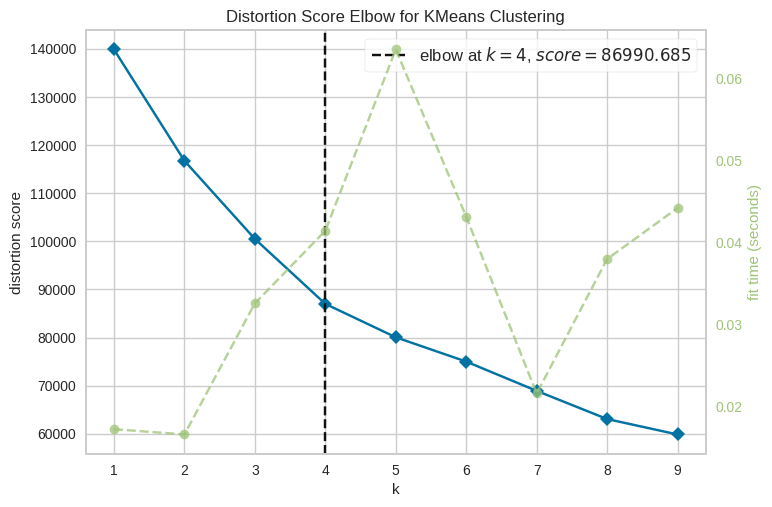

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [ ]:
from yellowbrick.cluster import KElbowVisualizer
from sklearn.cluster import KMeans

print('Elbow Method to determine the number of clusters to be formed:')

Elbow_M = KElbowVisualizer(KMeans(random_state=42), k=(1, 10))
Elbow_M.fit(data_pca)
Elbow_M.show()

# Agglomerative Clustering

It is a hierarchical clustering algorithm used in unsupervised machine learning and data analysis. It is a "bottom-up" or "agglomerative" approach to clustering, where individual data points are initially treated as their own clusters and then progressively merged into larger clusters based on a similarity or distance metric. The result is a tree-like structure called a dendrogram that represents the hierarchical relationships between clusters.

As always, You can find more detailed information about hierarchical clustering, including agglomerative clustering, in the Wikipedia article on "Hierarchical clustering" at the following link: [Hierarchical Clustering Wikipedia](https://en.wikipedia.org/wiki/Hierarchical_clustering). This is the best resource for hierarchical clustering and it is advisable to go through it twice if possible! :)

More ref: https://www.analyticsvidhya.com/blog/2019/05/beginners-guide-hierarchical-clustering/

**2 Dimensional Visualization**

In [ ]:
# Function for Agglomerative Clustering
def agglomerative_clustering(num_clusters):
    # Fit Agglomerative Clustering on PCA-reduced data
  agg_cluster = AgglomerativeClustering(n_clusters=num_clusters)
  agg_labels = agg_cluster.fit_predict(data_pca)

    # use PCA data for plotting
  plt.figure(figsize=(10, 7))
  plt.scatter(data_pca[:, 0], data_pca[:, 1], c=agg_labels, cmap='viridis', edgecolors='k')
    # Plot clusters (2D using first 2 principal components)
  plt.title(f'Agglomerative Clustering with {num_clusters} Clusters', fontsize=15)
  plt.xlabel('Principal Component 1', fontsize=12)
  plt.ylabel('Principal Component 2', fontsize=12)
  plt.legend(title='Cluster')
  plt.grid(True)
  plt.show()

interact(agglomerative_clustering, num_clusters=(2, 10, 1)) #here as well

interactive(children=(IntSlider(value=6, description='num_clusters', max=10, min=2), Output()), _dom_classes=(…

<function __main__.agglomerative_clustering(num_clusters)>

Similar to classification and regression metrics, we have some [clustering metrics](https://scikit-learn.org/stable/modules/classes.html#clustering-metrics) to evaluate performance.

We wll explore one of them: [silhouette_score](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.silhouette_score.html)

In [ ]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score

# Perform Agglomerative Clustering with 3 clusters
agglo = AgglomerativeClustering(n_clusters=3, linkage='average')
labels = agglo.fit_predict(data_pca)  # or use data_pca if you want PCA-reduced data

# Calculate Silhouette Score
silhouette = silhouette_score(data_pca, labels)  # or data_pca
print("Silhouette Score for 3 clusters:", silhouette)

Silhouette Score for 3 clusters: 0.8387829170309258


Explain Silhoutte score

Look into any 2 other metrics and give a brief explanation.

Do it here :)

1. silhouette score : it is a metric used to calculate how well a data point fits into its assigned cluster. A higher score is better coz it means that the clusters are dense and well-separated. It is based on two values:<br>
  a: avg distance to the other points in the same cluster.<br>
  b: avg distance to the points in the nearest neighboring cluster.<br>
  formula: (b - a) / max(a, b).

**3 Dimensional Visualization**

In [ ]:
from mpl_toolkits.mplot3d import Axes3D

# Function for 3D Agglomerative Clustering
def agglomerative_3d_clustering(num_clusters):
    # Fit Agglomerative Clustering
    agg_cluster_3d = AgglomerativeClustering(n_clusters=num_clusters)
    # using PCA data
    agg_labels_3d = agg_cluster_3d.fit_predict(data_pca)
    # 3D plot
    fig = plt.figure(figsize=(12, 8))
    ax = fig.add_subplot(111, projection='3d')
    scatter = ax.scatter(data_pca[:, 0], data_pca[:, 1], data_pca[:, 2], c=agg_labels_3d, cmap='viridis', s=40)

    ax.set_title(f'3D Agglomerative Clustering with {num_clusters} Clusters')
    ax.set_xlabel('Principal Component 1')
    ax.set_ylabel('Principal Component 2')
    ax.set_zlabel('Principal Component 3')
    plt.show()

# Interactive widget
interact(agglomerative_3d_clustering, num_clusters=(2, 10, 1)) #fill here


interactive(children=(IntSlider(value=6, description='num_clusters', max=10, min=2), Output()), _dom_classes=(…

<function __main__.agglomerative_3d_clustering(num_clusters)>

Look into what dendrograms are and plot them here.

Ref: https://docs.scipy.org/doc/scipy/reference/generated/scipy.cluster.hierarchy.dendrogram.html

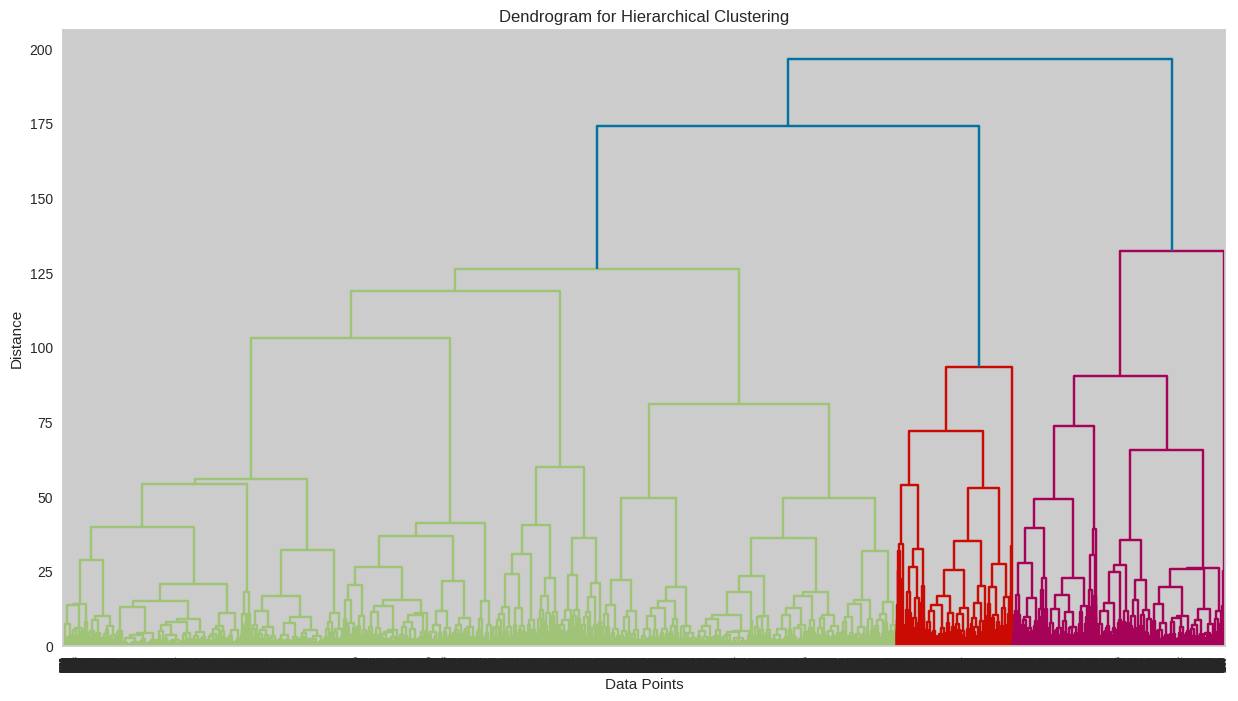

In [ ]:
#plot here
import scipy.cluster.hierarchy as sch
import matplotlib.pyplot as plt

# linkage matrix, which is what the dendrogram is based on
linked = sch.linkage(data_pca, method='ward')

# Create the dendrogram plot
plt.figure(figsize=(15, 8))
sch.dendrogram(linked, orientation='top', distance_sort='descending', show_leaf_counts=True)

plt.title('Dendrogram for Hierarchical Clustering')
plt.xlabel('Data Points')
plt.ylabel('Distance')
plt.show()

# DBSCAN Clustering

DBSCAN, which stands for Density-Based Spatial Clustering of Applications with Noise, is a popular density-based clustering algorithm in unsupervised machine learning. It is particularly useful for discovering clusters of arbitrary shapes in datasets with varying levels of data density. DBSCAN is known for its ability to handle noise and outliers effectively.

As always, You can find additional information about how DBSCAN clustering works in the following article on Analytics Vidhya:

[How DBSCAN Clustering Works](https://www.analyticsvidhya.com/blog/2020/09/how-dbscan-clustering-works/#:~:text=DBSCAN%20is%20a%20density%2Dbased,points%20into%20a%20single%20cluster.)

This article provides a detailed explanation of DBSCAN, including its underlying concepts, the role of epsilon (ε) and minimum points (MinPts), and practical examples of how to use DBSCAN for clustering. It's a valuable resource for gaining a deeper understanding of the algorithm with Wikipedia as the side resource.

Take a look at this short video to gain a better understanding of the concept:https://www.youtube.com/watch?v=RDZUdRSDOok

**2 Dimensional Visualization**

In [ ]:
# Perform DBSCAN clustering with interactive widget
def dbscan_clustering(eps, min_samples):
    dbscan = DBSCAN(eps=eps, min_samples=min_samples)
    dbscan_labels = dbscan.fit_predict(data_pca[:, :2]) #code here

    #plot here
    plt.figure(figsize=(10, 7))
    sns.scatterplot(x=data_pca[:, 0], y=data_pca[:, 1], hue=dbscan_labels, palette='viridis', s=50, legend='full')
    noise_points = data_pca[dbscan_labels == -1]
    if len(noise_points) > 0:
        plt.scatter(noise_points[:, 0], noise_points[:, 1], color='black', marker='x', s=100, label='Noise')

    plt.title(f'DBSCAN Clustering (eps={eps}, min_samples={min_samples})', fontsize=15)
    plt.xlabel('Principal Component 1', fontsize=12)
    plt.ylabel('Principal Component 2', fontsize=12)
    plt.legend(title='Cluster')
    plt.grid(True)
    plt.show()

# Interactive widget
interact(dbscan_clustering, eps=(0.1, 5.0, 0.1),min_samples=(2, 20, 1)) #fill here

interactive(children=(FloatSlider(value=2.5000000000000004, description='eps', max=5.0, min=0.1), IntSlider(va…

<function __main__.dbscan_clustering(eps, min_samples)>

**3 Dimensional Visualization**

In [ ]:
def dbscan_3d_clustering(eps, min_samples):
    #Write the complete function yourself
    dbscan_3d = DBSCAN(eps=eps, min_samples=min_samples)
    dbscan_labels_3d = dbscan_3d.fit_predict(data_pca)

    #plot here
    fig = plt.figure(figsize=(12, 8))
    ax = fig.add_subplot(111, projection='3d')

    non_noise_mask = dbscan_labels_3d != -1
    scatter = ax.scatter(data_pca[non_noise_mask, 0], data_pca[non_noise_mask, 1], data_pca[non_noise_mask, 2],
                         c=dbscan_labels_3d[non_noise_mask], cmap='viridis', s=40)

    noise_points = data_pca[dbscan_labels_3d == -1]

    if len(noise_points) > 0:
        ax.scatter(noise_points[:, 0], noise_points[:, 1], noise_points[:, 2], color='black', marker='x', s=100, label='Noise')

        # Set labels and title
    ax.set_title(f'3D DBSCAN Clustering (eps={eps}, min_samples={min_samples})')
    ax.set_xlabel('Principal Component 1')
    ax.set_ylabel('Principal Component 2')
    ax.set_zlabel('Principal Component 3')
    plt.show()

# Interactive widget
interact(dbscan_3d_clustering, eps=(0.1, 5.0, 0.1), min_samples=(2, 20, 1))


interactive(children=(FloatSlider(value=2.5000000000000004, description='eps', max=5.0, min=0.1), IntSlider(va…

<function __main__.dbscan_3d_clustering(eps, min_samples)>

After performing K-Means and Agglomerative clustering on the dataset, what differences and similarities did you notice between the two methods? What insights did you gain from the cluster patterns?

Answer:

similarities: <br>
- both of them group data based on distance without needing pre-labeled data. and for both methods, I had to specify the desired number of clusters to get a final result.

differences<br>
- K-Means is a top-down method that starts with a guess for the cluster centers and assigns points to them whereas Agglomerative clustering is a bottom-up method that starts with each point as its own cluster and merges them.

- i noticed K-Means tends to produce spherical, evenly sized clusters, but agglomerative clustering was more flexible and could create clusters of different shapes and sizes, depending on the linkage method used.

- K-Means only gives the final cluster assignments whereas Agglomerative clustering provides a full hierarchy via the dendrogram, which shows the relationships between clusters at all levels.

other thoughts:<br>
from the cluster patterns, I realised that K-Means is likely better for simple and well-separated market segments (e.g., high, medium, low spenders). Agglomerative clustering on the other hand, especially with the dendrogram, is mostly for discovering a more detailed structure in the data, like sub-groups within a larger customer segment.

# **Bonus: To be done only if you have completed the above tasks.**

In this task, we covered clustering and Dimensionality reduction. But still, one aspect of Unsupervised Learning is left to be covered- **Association rules**. Reseach about this topic and mention the different algos that exist.

 Also, look into the functioning of **Spectral Clustering algorithm** and mention it here :)

 The best reseach will be edited and featured on the Synapse Instagram page!!

## Association Rule Mining
Association Rule Mining is a technique to find hidden relationships between different items in a large dataset. It's famous for "*Market Basket Analysis*" but can be used anywhere we want to find "if-then" patterns.

Suppose, we have to analyze food purchase data to help vendors and student groups of our college. The goal is to find rules like:

"If a student buys Cold Coffee and Vada Pav at Anand Vada Pav, they are 80% likely to also buy a Frankie at NM Frankie during the same visit."

This insight could help the shop owners create combo offers or help student clubs plan events around these popular food choices.​

#### The strength of these Rules is measured by:
Support: How frequently do these items (Cold Coffee + Vada Pav + Frankie) appear together in student purchase records? For example, if this combination is common among all transactions, it has **high** support.​

Confidence: If a student buys Cold Coffee and Vada Pav, what is the probability they also buy a Frankie? For example, if 100 students buy the first two, and 80 also buy a Frankie with it, the confidence is 80%.​

Lift: How much more likely is a student to buy a Frankie given they bought the first two items, compared to any random student? A high lift means that this rule is not a random pattern.

Algorithms that exist:

- **Apriori**:
It finds frequent item combinations by first identifying popular single items, then pairs, then larger groups. It builds up from the simplest patterns to more complex ones, step by step. So, it finds which snack combos (like "Cold Coffee + Vada Pav") are most often bought together by checking singles, then pairs, then triples.

- **Eclat**:
It uses lists of transactions for each item and finds common combinations by intersecting these lists. It's faster because it works directly with who bought what. So, it will look at lists of students who bought each snack and quickly find which snacks are bought together by seeing whose names appear on both lists.

- **FP-Growth**:
This compresses all transactions into a tree structure (FP-Tree) and finds frequent patterns by exploring this tree, avoiding repeated scans of the data. In our example, it will build a tree of all snack purchase paths at Anand Vada Pav, then finds the most popular combos by exploring this tree.


### Spectral Clustering
Spectral Clustering is a more advanced clustering technique that's great at finding complex shapes. Here, instead of grouping data based on simple distance (K-Means), it identifies clusters based on how strongly they're connected, not just how close they are. It uses math to reveal hidden communities or clusters.

Continuing with our Anand Vadapav example, Spectral Clustering will:<br>
Group students who often eat together at Anand Vada Pav (even if they sometimes eat elsewhere). This will help understand real social circles between students based on shared eating habits.

Once you’ve completed all the tasks, feel free to make your submission even more impressive by adding sample code implementations or practical examples that demonstrate these algorithms in action.

# **End of Task**

> ©DJS Synapse 2025 - 2026